## 1 - Business Understanding (Aufgabendefinition) 
- Bestimmung der betriebswirtschaftlichen Problemstellung
- Situationsbewertung
- Bestimmung analytischer Ziele
- Erstellung eines Projektplans
- ---

### Bestimmung der betriebswirtschaftlichen Problemstellung
Ein Gebrauchtwagenhändler (GWH) möchte den Preis für verfügbare Gebrauchtwagen mittels eines Modells bestimmen. Bisher wird der Preis auf Basis der Erfahrungswerte der Mitarbeiter bestimmt. Der Preis soll für die Kunden und im Vergleich zum Markt akzeptabel sein und gleichzeitig eine hohe Marge für den Händler einbringen. Durch den Einsatz einer datenbasierten Entscheidungsunterstützung soll gezeigt werden, ob es Potenzial für höhere Margen gibt. 
### Situationsbewertung
Der GWH hat Daten über verkaufte Gebrauchtwagen über die Plattform kaggle bezogen. Die Grundlage für eine Datenanalyse ist damit vorhanden. Der aktuelle Prozess ist stark von der Erfahrung der jeweiligen Mitarbeiter abhängig. Ein datenbasierter und systemgestützter Prozess könnte diese starke Abhängigkeit entlasten und die Mitarbeiter bei Ihren Entscheidungen unterstützen. Es besteht die Chance neue Erkenntnisse aus Daten zu erlangen und bisher ungenutzte Potenziale zu heben.
### Bestimmung analytischer Ziele
Identifizierung von Clustern in den Daten und deren Einfluss auf das Ziel-Attribut „Preis“ 
### Erstellung eines Projektplans
Zusammenstellen eines Teams (Rollen, Verantwortungen festlegen)
Vorgehen nach den CRISP-DM (Phasen und Dauer planen)
Ergebnisse dem Auftraggeber präsentieren

---

## 2 - Data Understanding (Datenverständniss)
- Daten sammeln
- Daten beschreiben
- Untersuchung der Daten
- Verifizierung der Datenqualität
- ---

### 2.1 Daten sammeln

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Data: Based on Used Car data from https://www.kaggle.com/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/data

In [2]:
# Import Data sets

df = pd.read_csv("toyota.csv")

### 2.2 Daten beschreiben

In [3]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,GT86,2016,16000,Manual,24089,Petrol,265,36.2,2.0
1,GT86,2017,15995,Manual,18615,Petrol,145,36.2,2.0
2,GT86,2015,13998,Manual,27469,Petrol,265,36.2,2.0
3,GT86,2017,18998,Manual,14736,Petrol,150,36.2,2.0
4,GT86,2017,17498,Manual,36284,Petrol,145,36.2,2.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6738 entries, 0 to 6737
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         6738 non-null   object 
 1   year          6738 non-null   int64  
 2   price         6738 non-null   int64  
 3   transmission  6738 non-null   object 
 4   mileage       6738 non-null   int64  
 5   fuelType      6738 non-null   object 
 6   tax           6738 non-null   int64  
 7   mpg           6738 non-null   float64
 8   engineSize    6738 non-null   float64
dtypes: float64(2), int64(4), object(3)
memory usage: 473.9+ KB


In [5]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [6]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,6738.000000,6738.000000,6738.000000,6738.000000,6738.000000,6738.000000
mean,2016.748145,12522.391066,22857.413921,94.697240,63.042223,1.471297
std,2.204062,6345.017587,19125.464147,73.880776,15.836710,0.436159
min,1998.000000,850.000000,2.000000,0.000000,2.800000,0.000000
25%,2016.000000,8290.000000,9446.000000,0.000000,55.400000,1.000000
50%,2017.000000,10795.000000,18513.000000,135.000000,62.800000,1.500000
75%,2018.000000,14995.000000,31063.750000,145.000000,69.000000,1.800000
max,2020.000000,59995.000000,174419.000000,565.000000,235.000000,4.500000


In [7]:
df.shape

(6738, 9)

### 2.3 Untersuchung der Daten (EDA)

### Univariate Analysis

In [8]:
def skalenniveau_bestimmen(df):
    if df.dtype == 'object':  # Kategorische Daten
        # Falls es nur wenige eindeutige Werte gibt, könnte es Nominal oder Ordinal sein.
        unique_values = df.nunique()
        if unique_values <= 10:
            return "Nominal (kategorisch)"
        else:
            return "Ordinal (Reihenfolge vorhanden)"
    
    elif pd.api.types.is_numeric_dtype(df):
        if (df.min() == 0) and (df.max() > 0):  # Echte Null vorhanden (Verhältnisskala)
            return "Verhältnisskala"
        else:  # Intervalldaten
            return "Intervallskala"
    
    return "Unklar"

# Beispiel anwenden
print('model', skalenniveau_bestimmen(df['model']))  # Nominal
print('year', skalenniveau_bestimmen(df['year']))  # Verhältnisskala
print('price', skalenniveau_bestimmen(df['price']))  # Ordinal
print('transmission', skalenniveau_bestimmen(df['transmission']))  # Nominal
print('mileage', skalenniveau_bestimmen(df['mileage']))  # Verhältnisskala
print('fuelType', skalenniveau_bestimmen(df['fuelType']))  # Nominal
print('tax', skalenniveau_bestimmen(df['tax']))  # Verhältnisskala
print('mpg', skalenniveau_bestimmen(df['mpg']))  # Verhältnisskala
print('engineSize', skalenniveau_bestimmen(df['engineSize']))  # Verhältnisskala

model Ordinal (Reihenfolge vorhanden)
year Intervallskala
price Intervallskala
transmission Nominal (kategorisch)
mileage Intervallskala
fuelType Nominal (kategorisch)
tax Verhältnisskala
mpg Intervallskala
engineSize Verhältnisskala


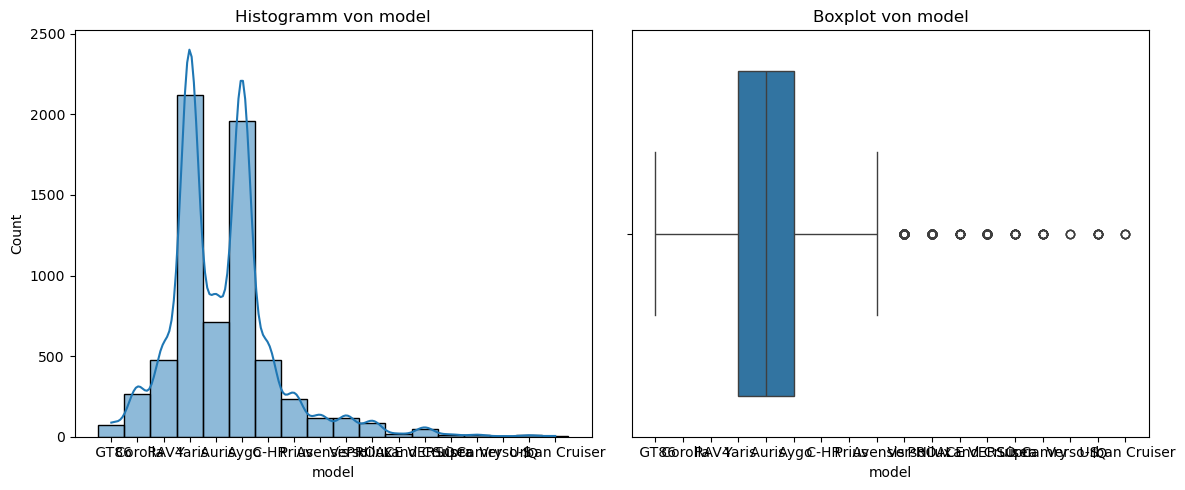

In [36]:
# Histogramm & Boxplot for numerical variables
# num_col = "year"  
# num_col = "price" 
# num_col = "mileage"  
# num_col = "tax"  
#num_col = "mpg"  
# num_col = "engineSize"
num_col = 'model'

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[num_col], kde=True)
plt.title(f'Histogramm von {num_col}')

plt.subplot(1, 2, 2)
sns.boxplot(x=df[num_col])
plt.title(f'Boxplot von {num_col}')

plt.tight_layout()
plt.show()

fuelType
Petrol    4087
Hybrid    2043
Diesel     503
Other      105
Name: count, dtype: int64


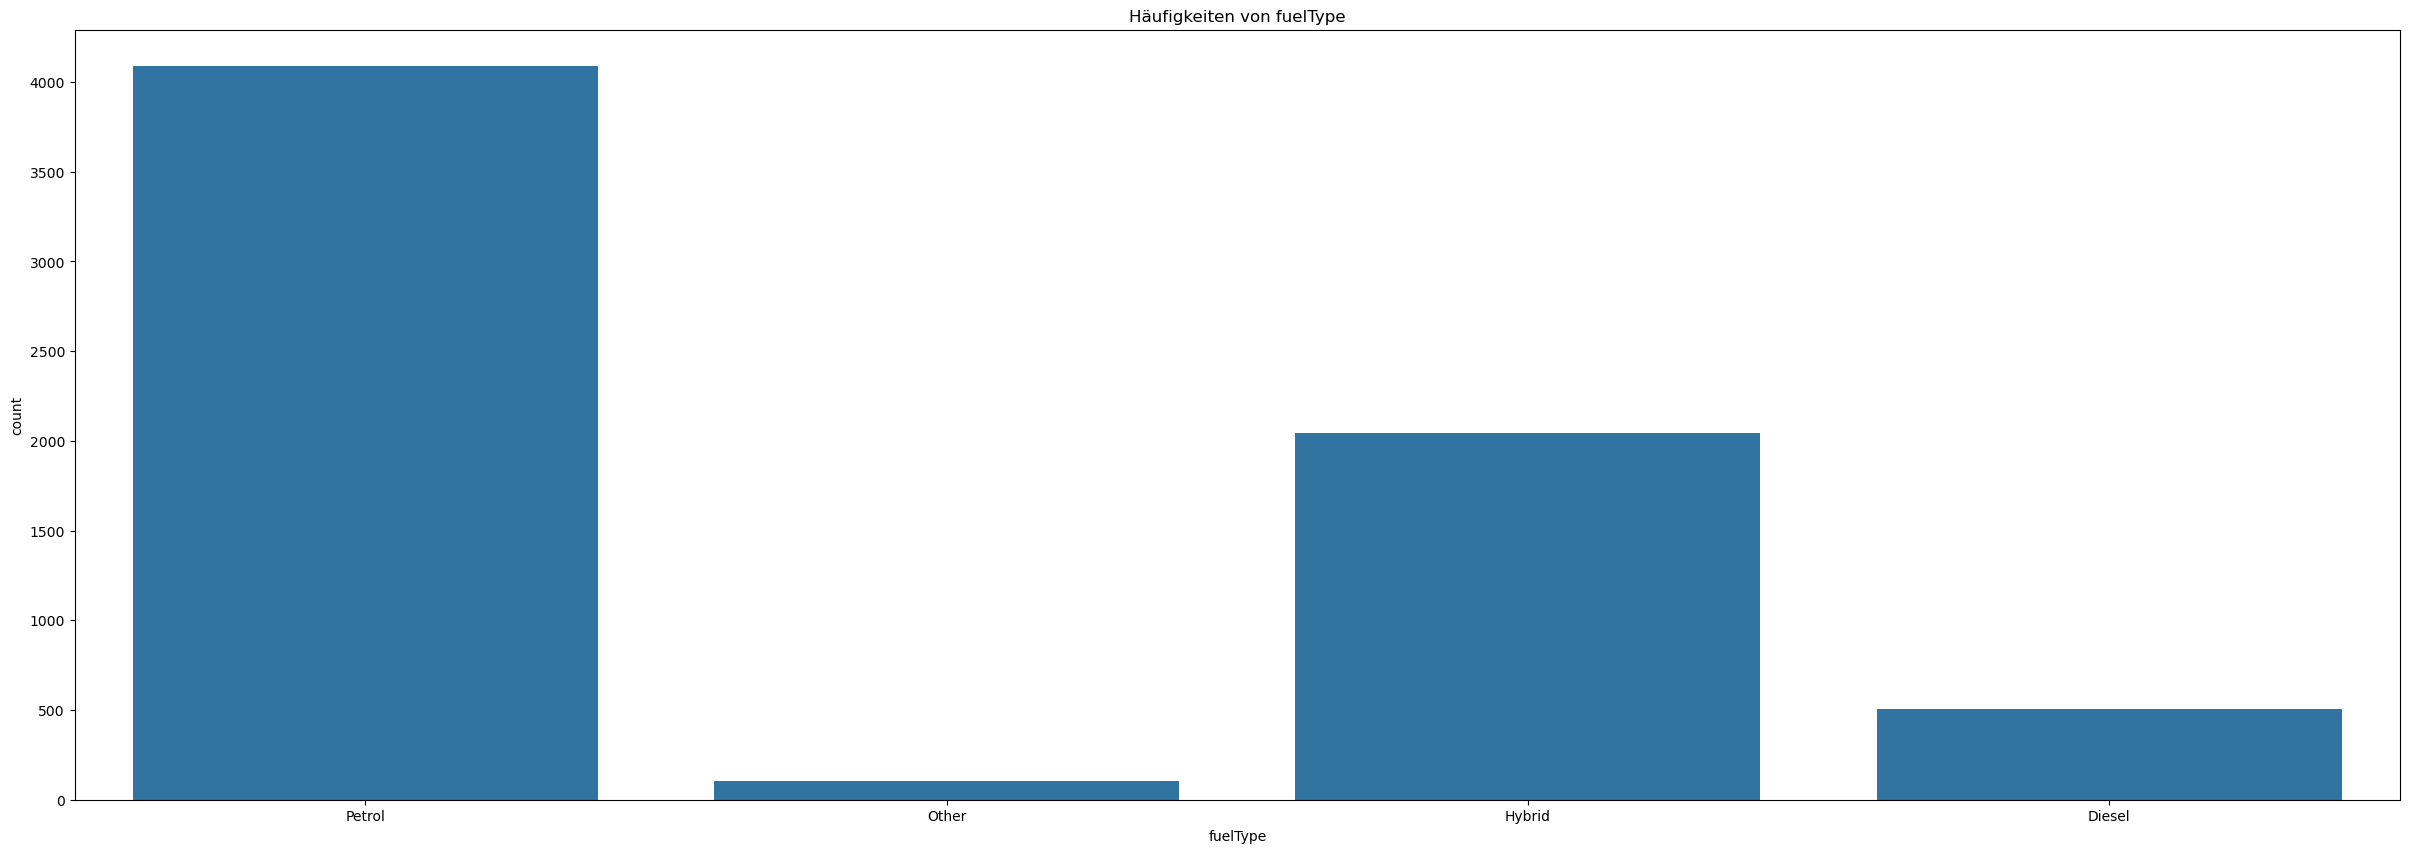

In [40]:
# for nomminal variables
# cat_col = "model"
# cat_col = "tax" 
cat_col = "fuelType"  

print(df[cat_col].value_counts())

# Balkendiagramm
plt.figure(figsize=(30, 10))
sns.countplot(x=df[cat_col])
plt.title(f'Häufigkeiten von {cat_col}')
plt.show()


### Bivariate Analysis

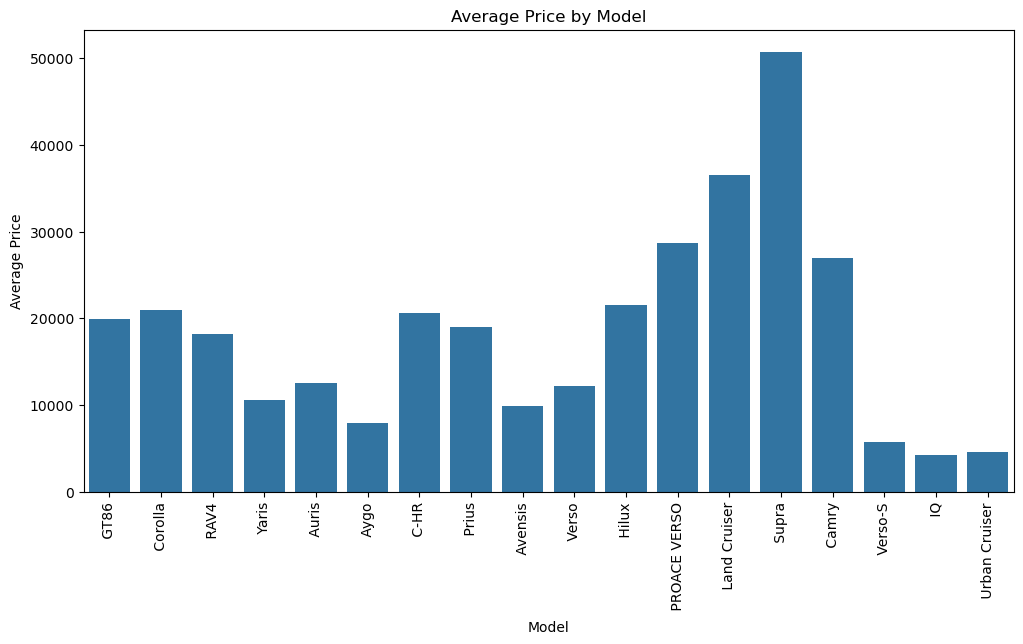

In [30]:
plt.figure(figsize=(12, 6))
sns.barplot(x='model', y='price', data=df[:10000], errorbar=None)
plt.title('Average Price by Model')
plt.xlabel('Model')
plt.ylabel('Average Price')
plt.xticks(rotation=90)  
plt.show()

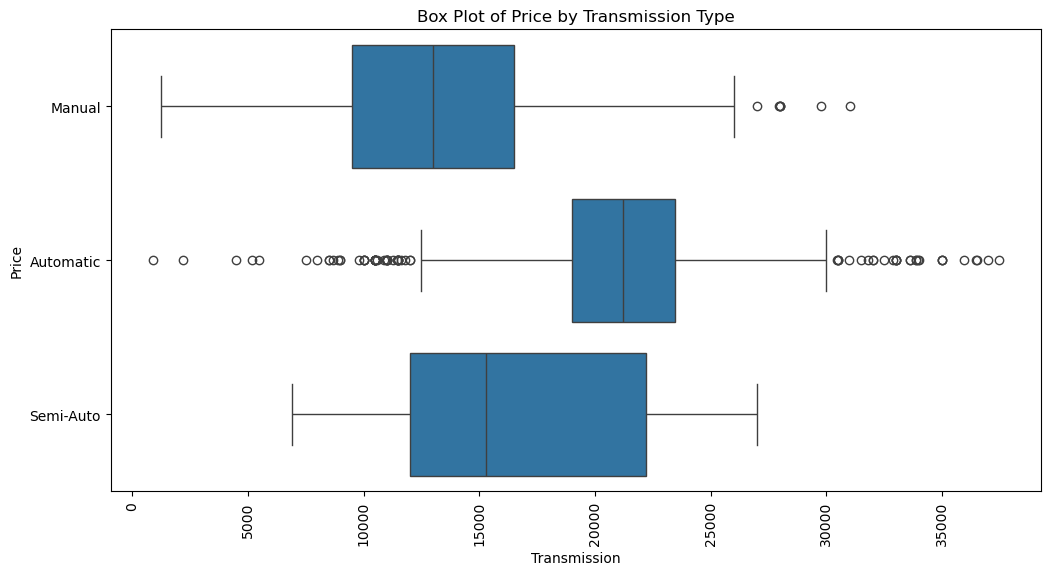

In [21]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='price', y='transmission', data=df[:1000],orient='h')
plt.title('Box Plot of Price by Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Price')
plt.xticks(rotation=90) 
plt.show()

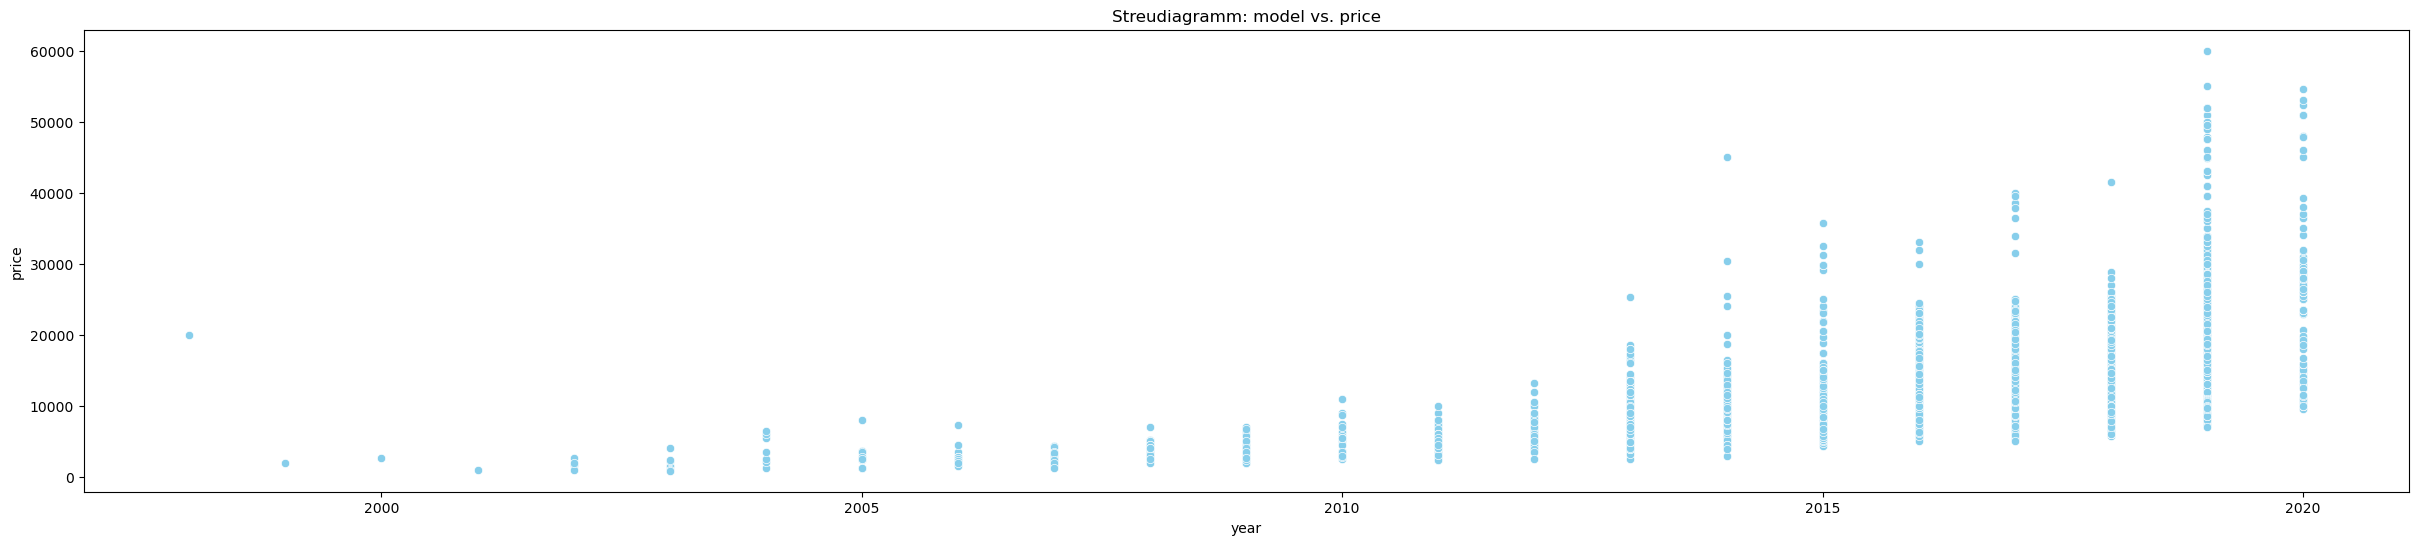

In [31]:
import seaborn as sns

# Streudiagramm mit seaborn erstellen
plt.figure(figsize=(30, 6))
sns.scatterplot(data=df, x='year', y='price', color='skyblue')

# Titel hinzufügen
plt.title('Streudiagramm: model vs. price')

# Diagramm anzeigen
plt.show()

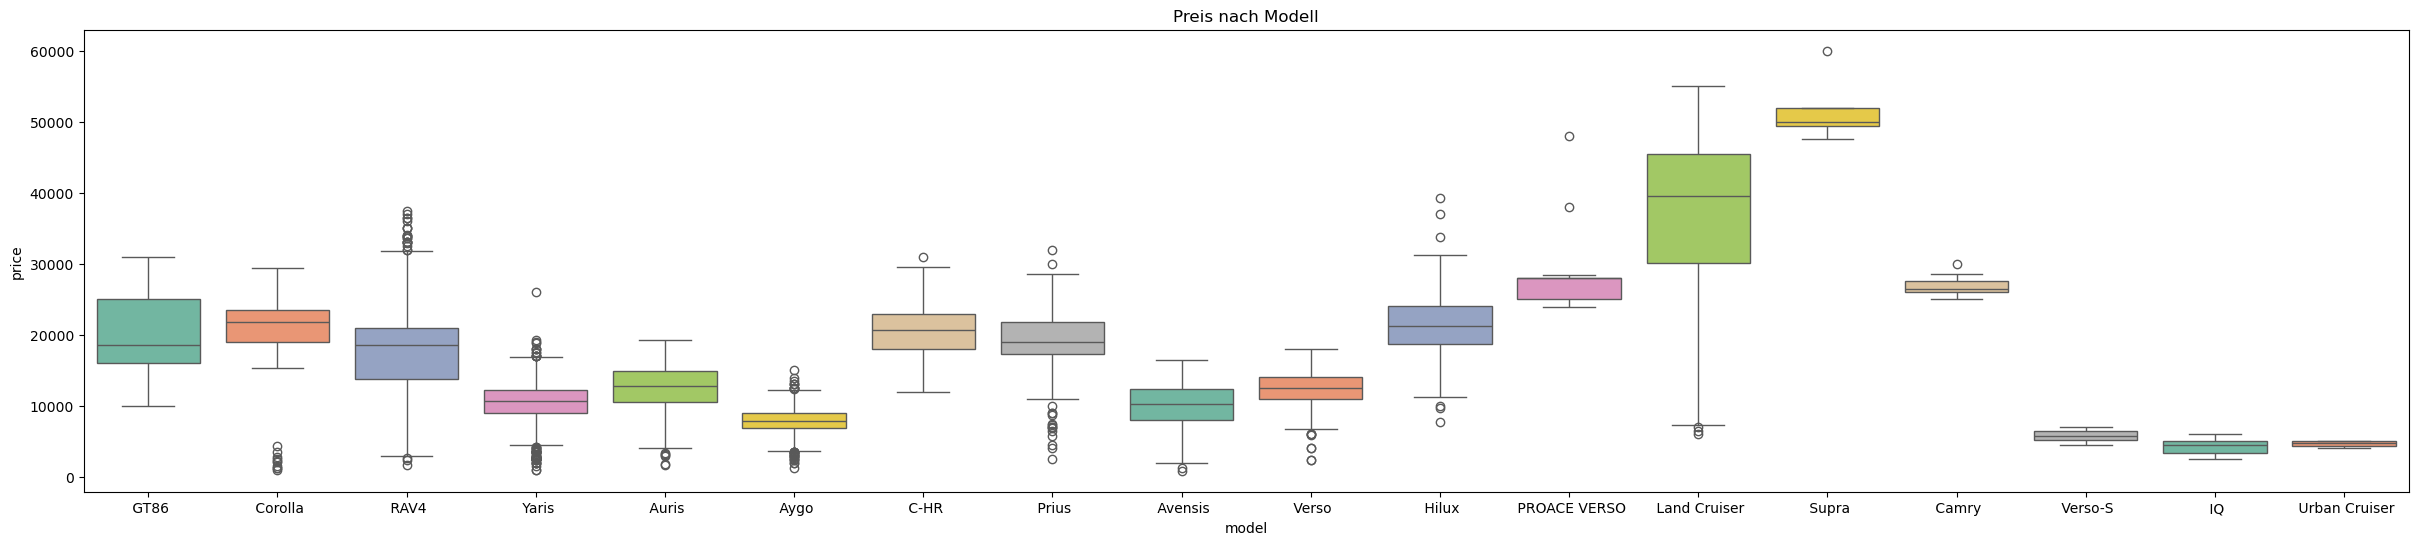

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot erstellen mit hue anstelle von palette
plt.figure(figsize=(30, 6))
sns.boxplot(x='model', y='price', data=df, hue='model', palette='Set2', legend=False)

# Titel hinzufügen
plt.title('Preis nach Modell')

# Diagramm anzeigen
plt.show()

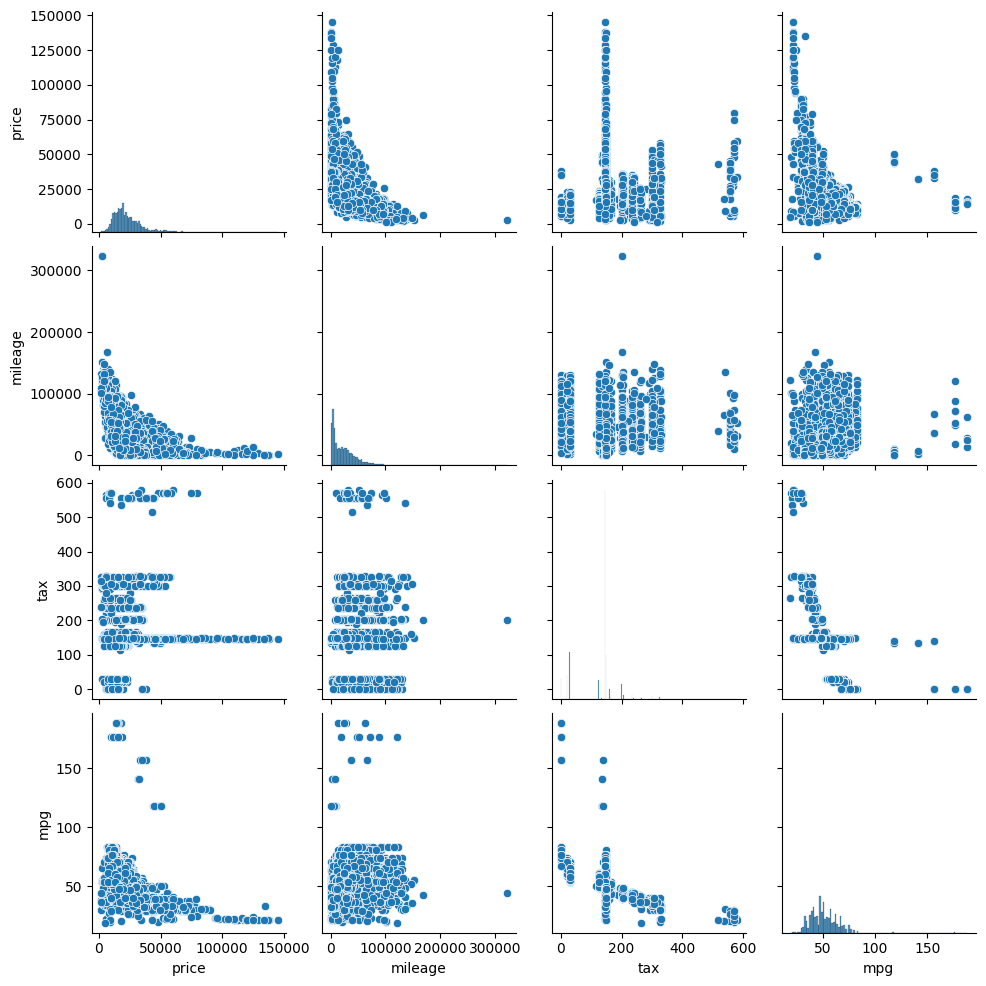

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pairplot für price und mileage
sns.pairplot(df[['price', 'mileage', 'tax', 'transmission', 'mpg']])

# Diagramm anzeigen
plt.show()

### 2.4 Verifizierung der Datenqualität

In [41]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [42]:
# how many total missing values do we have?
total_cells = np.prod(df.shape)
total_missing = df.isnull().sum()

# percent of data that is missing
percent_missing = (total_missing/total_cells) * 100
print(percent_missing)

model           0.0
year            0.0
price           0.0
transmission    0.0
mileage         0.0
fuelType        0.0
tax             0.0
mpg             0.0
engineSize      0.0
dtype: float64


In [43]:
df.dropna()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,GT86,2016,16000,Manual,24089,Petrol,265,36.2,2.0
1,GT86,2017,15995,Manual,18615,Petrol,145,36.2,2.0
2,GT86,2015,13998,Manual,27469,Petrol,265,36.2,2.0
3,GT86,2017,18998,Manual,14736,Petrol,150,36.2,2.0
4,GT86,2017,17498,Manual,36284,Petrol,145,36.2,2.0
...,...,...,...,...,...,...,...,...,...
6733,IQ,2011,5500,Automatic,30000,Petrol,20,58.9,1.0
6734,Urban Cruiser,2011,4985,Manual,36154,Petrol,125,50.4,1.3
6735,Urban Cruiser,2012,4995,Manual,46000,Diesel,125,57.6,1.4
6736,Urban Cruiser,2011,3995,Manual,60700,Petrol,125,50.4,1.3


In [51]:
columns_with_na_dropped = df.dropna(axis=1)
columns_with_na_dropped.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,GT86,2016,16000,Manual,24089,Petrol,265,36.2,2.0
1,GT86,2017,15995,Manual,18615,Petrol,145,36.2,2.0
2,GT86,2015,13998,Manual,27469,Petrol,265,36.2,2.0
3,GT86,2017,18998,Manual,14736,Petrol,150,36.2,2.0
4,GT86,2017,17498,Manual,36284,Petrol,145,36.2,2.0


In [50]:
# just how much data did we lose?
print("Columns in original dataset: %d \n" % df.shape[1])
print("Columns with na's dropped: %d" % columns_with_na_dropped.shape[1])

Columns in original dataset: 9 

Columns with na's dropped: 9


In [45]:
df.fillna(0)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,GT86,2016,16000,Manual,24089,Petrol,265,36.2,2.0
1,GT86,2017,15995,Manual,18615,Petrol,145,36.2,2.0
2,GT86,2015,13998,Manual,27469,Petrol,265,36.2,2.0
3,GT86,2017,18998,Manual,14736,Petrol,150,36.2,2.0
4,GT86,2017,17498,Manual,36284,Petrol,145,36.2,2.0
...,...,...,...,...,...,...,...,...,...
6733,IQ,2011,5500,Automatic,30000,Petrol,20,58.9,1.0
6734,Urban Cruiser,2011,4985,Manual,36154,Petrol,125,50.4,1.3
6735,Urban Cruiser,2012,4995,Manual,46000,Diesel,125,57.6,1.4
6736,Urban Cruiser,2011,3995,Manual,60700,Petrol,125,50.4,1.3


In [52]:
df.duplicated().sum()

39

In [53]:
# Duplikate anzeigen (alle Spalten vergleichen)
duplikate = df[df.duplicated()]
print("Einfache Duplikate:")
print(duplikate)

Einfache Duplikate:
         model  year  price transmission  mileage fuelType  tax   mpg  \
178    Corolla  2019  17960       Manual     4500   Petrol  145  39.2   
286    Corolla  2019  15991       Manual       10   Petrol  145  39.2   
397       RAV4  2016  17495    Automatic    58100   Hybrid   20  55.4   
398       RAV4  2017  16295       Manual    34633   Diesel  125  60.1   
446       RAV4  2014  10999       Manual    57942   Diesel  145  53.0   
459       RAV4  2015  13500       Manual    45757   Diesel  125  57.6   
460       RAV4  2015  13500       Manual    45757   Diesel  125  57.6   
764       RAV4  2016  18795    Automatic    57000   Hybrid   20  55.4   
1178     Yaris  2016  10495    Automatic    33705   Hybrid    0  86.0   
1414     Yaris  2016   9495    Automatic    26191   Petrol   30  58.0   
1587     Yaris  2020  14769       Manual       25   Petrol  150  47.9   
1964     Yaris  2019  12495    Automatic     6000   Petrol  145  47.9   
2161     Yaris  2019  14495    

In [54]:
# Duplikate inklusive des ersten Auftretens anzeigen
duplikate_mit_erstem = df[df.duplicated(keep=False)]
print("\nAlle Duplikate (inkl. erstes Vorkommen):")
print(duplikate_mit_erstem)


Alle Duplikate (inkl. erstes Vorkommen):
         model  year  price transmission  mileage fuelType  tax   mpg  \
177    Corolla  2019  17960       Manual     4500   Petrol  145  39.2   
178    Corolla  2019  17960       Manual     4500   Petrol  145  39.2   
285    Corolla  2019  15991       Manual       10   Petrol  145  39.2   
286    Corolla  2019  15991       Manual       10   Petrol  145  39.2   
344       RAV4  2015  13500       Manual    45757   Diesel  125  57.6   
...        ...   ...    ...          ...      ...      ...  ...   ...   
5560      Aygo  2019  10750       Manual       32   Petrol  145  57.7   
6356   Avensis  2017  10595       Manual    35939   Diesel  145  67.3   
6357   Avensis  2017  10595       Manual    35939   Diesel  145  67.3   
6569     Hilux  2015  14995    Automatic    72100   Diesel  260  32.8   
6570     Hilux  2015  14995    Automatic    72100   Diesel  260  32.8   

      engineSize  
177          1.2  
178          1.2  
285          1.2  
286  

In [55]:
df_cleaned = df.drop_duplicates()

---
## 3 - Data Preparation (Datenaufbereitung)
- Auswahl der Daten
- Bereinigung der Daten
- Transformation und Integration der Daten
- Datenformatierung
- ---

### 3.1 Auswahl der Daten

### 3.2 Bereinigung der Daten

In [56]:
df_cleaned = df.drop_duplicates()

### Ausreißer nach IQR Methode

Bereinigter DataFrame:
               model  year  price transmission  mileage fuelType  tax   mpg  \
0               GT86  2016  16000       Manual    24089   Petrol  265  36.2   
1               GT86  2017  15995       Manual    18615   Petrol  145  36.2   
2               GT86  2015  13998       Manual    27469   Petrol  265  36.2   
3               GT86  2017  18998       Manual    14736   Petrol  150  36.2   
4               GT86  2017  17498       Manual    36284   Petrol  145  36.2   
...              ...   ...    ...          ...      ...      ...  ...   ...   
6733              IQ  2011   5500    Automatic    30000   Petrol   20  58.9   
6734   Urban Cruiser  2011   4985       Manual    36154   Petrol  125  50.4   
6735   Urban Cruiser  2012   4995       Manual    46000   Diesel  125  57.6   
6736   Urban Cruiser  2011   3995       Manual    60700   Petrol  125  50.4   
6737   Urban Cruiser  2011   4495       Manual    45128   Petrol  125  50.4   

      engineSize  
0        

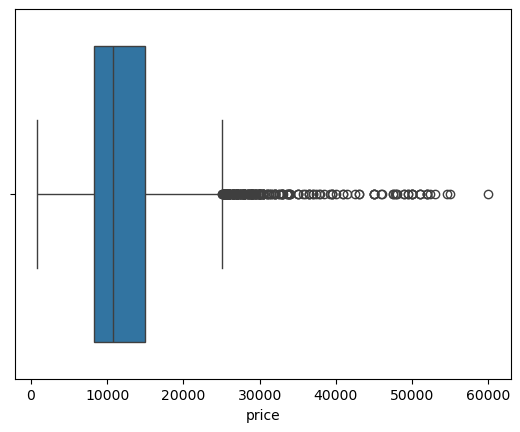

In [58]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# IQR-Methode
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Grenzen für Ausreißer
untere_grenze = Q1 - 1.5 * IQR
obere_grenze = Q3 + 1.5 * IQR

# Nur Zeilen behalten, die keine Ausreißer sind
df_cleaned = df#df[(df['price'] >= untere_grenze) & (df['price'] <= obere_grenze)]

print("Bereinigter DataFrame:")
print(df_cleaned)

# check with boxplot
sns.boxplot(x=df_cleaned['price'])
plt.show()


### Mehrere Ausreißer nach IQR Methode

In [60]:
import pandas as pd

# Nur numerische Spalten auswählen
num_cols = df.select_dtypes(include='number').columns

# Kopie für Bereinigung
df_clean = df.copy()

# Zeilen-Indexe mit Ausreißern sammeln
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter anwenden – nur Werte innerhalb der Grenzen behalten
    df_clean = df#df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

print(df_clean)


               model  year  price transmission  mileage fuelType  tax   mpg  \
0               GT86  2016  16000       Manual    24089   Petrol  265  36.2   
1               GT86  2017  15995       Manual    18615   Petrol  145  36.2   
2               GT86  2015  13998       Manual    27469   Petrol  265  36.2   
3               GT86  2017  18998       Manual    14736   Petrol  150  36.2   
4               GT86  2017  17498       Manual    36284   Petrol  145  36.2   
...              ...   ...    ...          ...      ...      ...  ...   ...   
6733              IQ  2011   5500    Automatic    30000   Petrol   20  58.9   
6734   Urban Cruiser  2011   4985       Manual    36154   Petrol  125  50.4   
6735   Urban Cruiser  2012   4995       Manual    46000   Diesel  125  57.6   
6736   Urban Cruiser  2011   3995       Manual    60700   Petrol  125  50.4   
6737   Urban Cruiser  2011   4495       Manual    45128   Petrol  125  50.4   

      engineSize  
0            2.0  
1            

### Ausreißer nach Z-Score Methode

In [66]:
from scipy.stats import zscore

# Z-Scores berechnen
df['z_score'] = zscore(df['price'])

# Nur Werte mit Z-Score < 3 behalten
df_cleaned = df#df[df['z_score'].abs() < 3].drop(columns='z_score')

print("Bereinigter DataFrame:")
print(df_cleaned)


Bereinigter DataFrame:
               model  year  price transmission  mileage fuelType  tax   mpg  \
0               GT86  2016  16000       Manual    24089   Petrol  265  36.2   
1               GT86  2017  15995       Manual    18615   Petrol  145  36.2   
2               GT86  2015  13998       Manual    27469   Petrol  265  36.2   
3               GT86  2017  18998       Manual    14736   Petrol  150  36.2   
4               GT86  2017  17498       Manual    36284   Petrol  145  36.2   
...              ...   ...    ...          ...      ...      ...  ...   ...   
6733              IQ  2011   5500    Automatic    30000   Petrol   20  58.9   
6734   Urban Cruiser  2011   4985       Manual    36154   Petrol  125  50.4   
6735   Urban Cruiser  2012   4995       Manual    46000   Diesel  125  57.6   
6736   Urban Cruiser  2011   3995       Manual    60700   Petrol  125  50.4   
6737   Urban Cruiser  2011   4495       Manual    45128   Petrol  125  50.4   

      engineSize   z_score  

### 3.3  Transformation und Integration der Daten

### Label Encodig (für ordinale oder nominale Daten mit wenigen Kategorien)

In [67]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Beispiel-Daten
#df = pd.DataFrame({'Farbe': ['rot', 'blau', 'grün', 'rot', 'blau']})

# LabelEncoder anwenden
encoder = LabelEncoder()
df['model_num'] = encoder.fit_transform(df['model'])

print(df)


               model  year  price transmission  mileage fuelType  tax   mpg  \
0               GT86  2016  16000       Manual    24089   Petrol  265  36.2   
1               GT86  2017  15995       Manual    18615   Petrol  145  36.2   
2               GT86  2015  13998       Manual    27469   Petrol  265  36.2   
3               GT86  2017  18998       Manual    14736   Petrol  150  36.2   
4               GT86  2017  17498       Manual    36284   Petrol  145  36.2   
...              ...   ...    ...          ...      ...      ...  ...   ...   
6733              IQ  2011   5500    Automatic    30000   Petrol   20  58.9   
6734   Urban Cruiser  2011   4985       Manual    36154   Petrol  125  50.4   
6735   Urban Cruiser  2012   4995       Manual    46000   Diesel  125  57.6   
6736   Urban Cruiser  2011   3995       Manual    60700   Petrol  125  50.4   
6737   Urban Cruiser  2011   4495       Manual    45128   Petrol  125  50.4   

      engineSize   z_score  model_num  
0          

### One-Hot Encoding (für nominale Daten, wenn keine Ordnung existiert)

In [68]:
# One-Hot-Encoding für die Spalte "model"
# Die encodierten Spalten dem Original-DataFrame hinzufügen
df_encoded = pd.get_dummies(df_clean, columns=['model', 'transmission', 'fuelType'])
#df_encoded = pd.get_dummies(df, columns=['model', 'transmission', 'fuelType'])

print(df_encoded)


      year  price  mileage  tax   mpg  engineSize   z_score  model_num  \
0     2016  16000    24089  265  36.2         2.0  0.548126          6   
1     2017  15995    18615  145  36.2         2.0  0.547338          6   
2     2015  13998    27469  265  36.2         2.0  0.232579          6   
3     2017  18998    14736  150  36.2         2.0  1.020657          6   
4     2017  17498    36284  145  36.2         2.0  0.784234          6   
...    ...    ...      ...  ...   ...         ...       ...        ...   
6733  2011   5500    30000   20  58.9         1.0 -1.106839          8   
6734  2011   4985    36154  125  50.4         1.3 -1.188011         14   
6735  2012   4995    46000  125  57.6         1.4 -1.186435         14   
6736  2011   3995    60700  125  50.4         1.3 -1.344050         14   
6737  2011   4495    45128  125  50.4         1.3 -1.265243         14   

      model_ Auris  model_ Avensis  ...  model_ Verso-S  model_ Yaris  \
0            False           False  ..

### 3.4 Datenformatierung

### Min-Max-Normalisierung

In [72]:
# Min-Max-Normalisierung der Gehalt-Spalte
# df['mileage_norm'] = (df['mileage'] - df['mileage'].min()) / (df['mileage'].max() - df['mileage'].min())

print(df['mileage_norm'])


0       0.138100
1       0.106716
2       0.157479
3       0.084476
4       0.208019
          ...   
6733    0.171990
6734    0.207273
6735    0.263724
6736    0.348005
6737    0.258725
Name: mileage_norm, Length: 6738, dtype: float64


### Z-Score-Normalisierung 

In [73]:
# Z-Score-Normalisierung der Gehalt-Spalte
# df['mileage_std'] = (df['mileage'] - df['mileage'].mean()) / df['mileage'].std()

print(df['mileage_std'])


0       0.064395
1      -0.221820
2       0.241123
3      -0.424639
4       0.702027
          ...   
6733    0.373459
6734    0.695229
6735    1.210040
6736    1.978649
6737    1.164447
Name: mileage_std, Length: 6738, dtype: float64


### Mehrere Spalten auf einmal mit sklearn

In [77]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler = StandardScaler()  # Oder: StandardScaler()
df_scaled = df_encoded.copy()
df_scaled[num_cols] = scaler.fit_transform(df_encoded[num_cols])

print(df_scaled)

          year     price   mileage       tax       mpg  engineSize   z_score  \
0    -0.339464  0.548126  0.064400  2.305274 -1.695063    1.212270  0.548126   
1     0.114277  0.547338 -0.221837  0.680915 -1.695063    1.212270  0.547338   
2    -0.793206  0.232579  0.241141  2.305274 -1.695063    1.212270  0.232579   
3     0.114277  1.020657 -0.424670  0.748596 -1.695063    1.212270  1.020657   
4     0.114277  0.784234  0.702079  0.680915 -1.695063    1.212270  0.784234   
...        ...       ...       ...       ...       ...         ...       ...   
6733 -2.608171 -1.106839  0.373487 -1.011126 -0.261578   -1.080644 -1.106839   
6734 -2.608171 -1.188011  0.695281  0.410188 -0.798345   -0.392770 -1.188011   
6735 -2.154430 -1.186435  1.210130  0.410188 -0.343672   -0.163478 -1.186435   
6736 -2.608171 -1.344050  1.978796  0.410188 -0.798345   -0.392770 -1.344050   
6737 -2.608171 -1.265243  1.164533  0.410188 -0.798345   -0.392770 -1.265243   

      model_num  model_ Auris  model_ A

---
## 4 - Modeling (Modellierung)
- Auswahl des Modells
- Testmodell erstellen
- Modell erstellen
- ---

### 4.1  Auswahl des Modells

### 4.2 Testmodell erstellen

### 4.3 Modell erstellen

### einfaches Modell ohne transformationen

In [84]:
from sklearn.cluster import KMeans

X = df.loc[:, ["price", "mileage", "year"]]
X.head()

# Create cluster feature
kmeans = KMeans(n_clusters=4, random_state=0)
X["Cluster"] = kmeans.fit_predict(X)
X["Cluster"] = X["Cluster"].astype("category")

X.head()

,price,mileage,year,Cluster
0,16000,24089,2016,0
1,15995,18615,2017,0
2,13998,27469,2015,0
3,18998,14736,2017,2
4,17498,36284,2017,1


In [85]:
import pandas as pd

# Maximale Anzahl angezeigter Spalten erhöhen
pd.set_option('display.max_columns', None)  # zeigt alle Spalten

# Optional: Zeilen auch erhöhen
pd.set_option('display.max_rows', None)


In [87]:
# Übersicht über alle numerischen Merkmale pro Cluster
cluster_summary = X.groupby('Cluster').agg(['count', 'mean', 'median', 'min', 'max'])

# Nur relevante Spalten (optional)
numerical_cols = ['mileage', 'price', 'year']
summary = X.groupby('Cluster')[numerical_cols].describe()

print(summary)


        mileage                                                          \
          count          mean           std      min       25%      50%   
Cluster                                                                   
0        2412.0  24719.161692   5387.250483  15416.0  20115.00  24101.0   
1        1055.0  46244.931754   8185.658777  35256.0  39738.00  44052.0   
2        3040.0   8415.838816   4640.153443      2.0   4586.75   8761.0   
3         231.0  86658.372294  20695.930058  66000.0  71595.00  80000.0   

                             price                                             \
             75%       max   count          mean          std     min     25%   
Cluster                                                                         
0        29335.0   36137.0  2412.0  11499.354478  4879.151120  2695.0  7698.0   
1        52000.0   66661.0  1055.0  10486.098578  4668.249564  2490.0  6872.5   
2        12123.5   18645.0  3040.0  14482.654934  7259.773609  5273.0

C:\Users\sangermann\AppData\Local\Temp\ipykernel_17280\2321660960.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_summary = X.groupby('Cluster').agg(['count', 'mean', 'median', 'min', 'max'])
C:\Users\sangermann\AppData\Local\Temp\ipykernel_17280\2321660960.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = X.groupby('Cluster')[numerical_cols].describe()


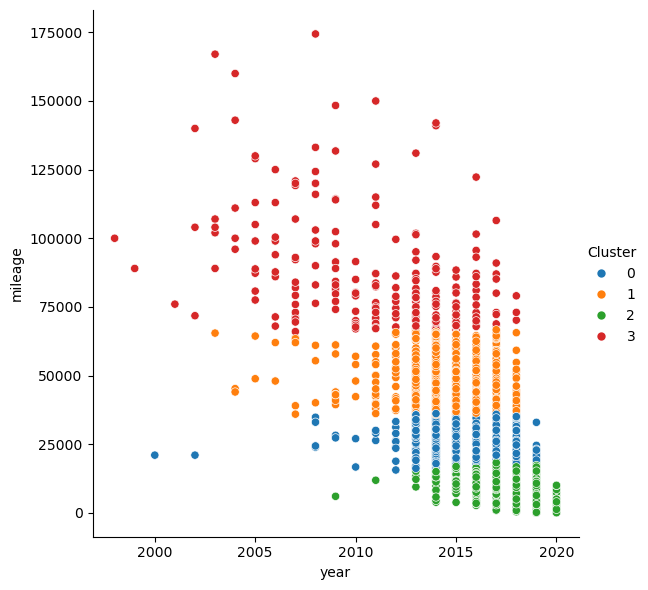

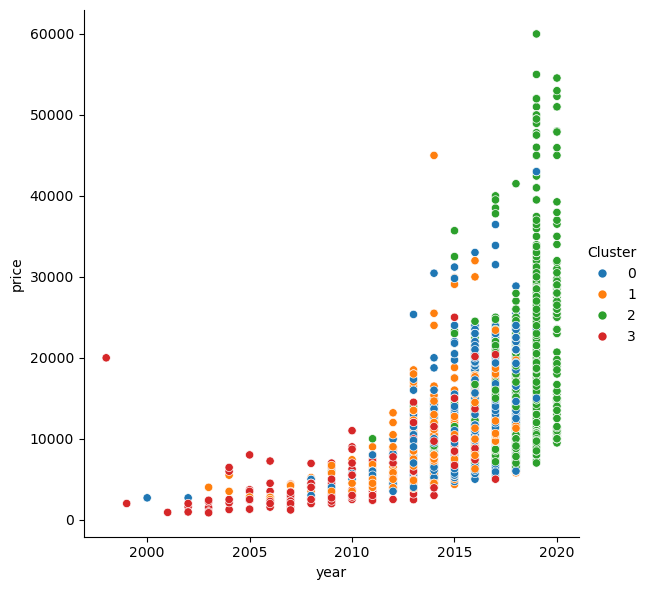

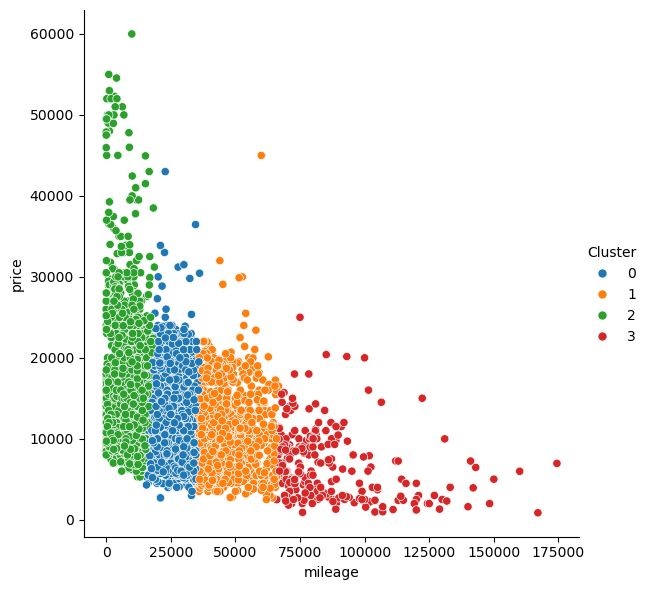

In [91]:
sns.relplot(
    x="year", y="mileage", hue="Cluster", data=X, height=6,
);
sns.relplot(
    x="year", y="price", hue="Cluster", data=X, height=6,
);
sns.relplot(
    x="mileage", y="price", hue="Cluster", data=X, height=6,
);

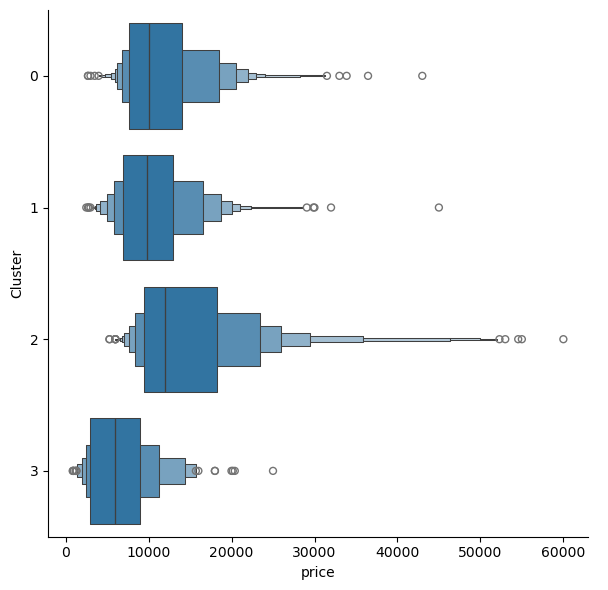

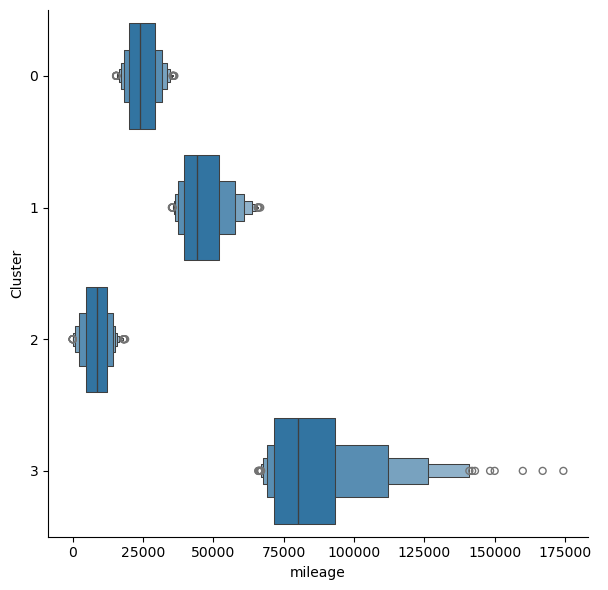

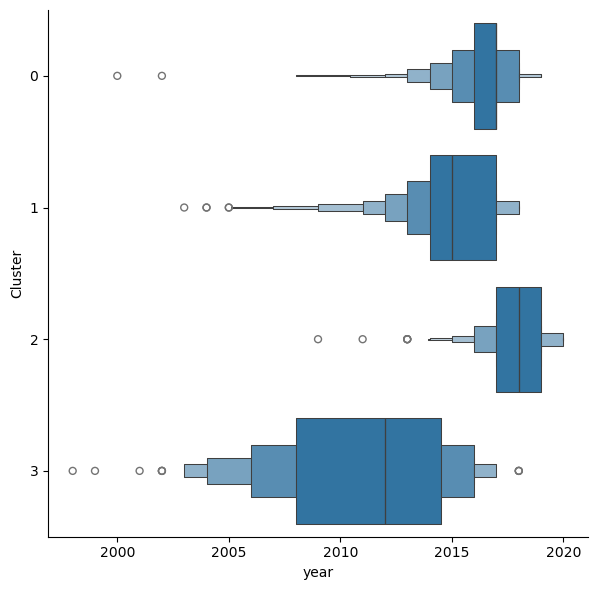

In [90]:
X["price"] = df["price"]
X["mileage"] = df["mileage"]
X["year"] = df["year"]
sns.catplot(x="price", y="Cluster", data=X, kind="boxen", height=6);
sns.catplot(x="mileage", y="Cluster", data=X, kind="boxen", height=6);
sns.catplot(x="year", y="Cluster", data=X, kind="boxen", height=6);

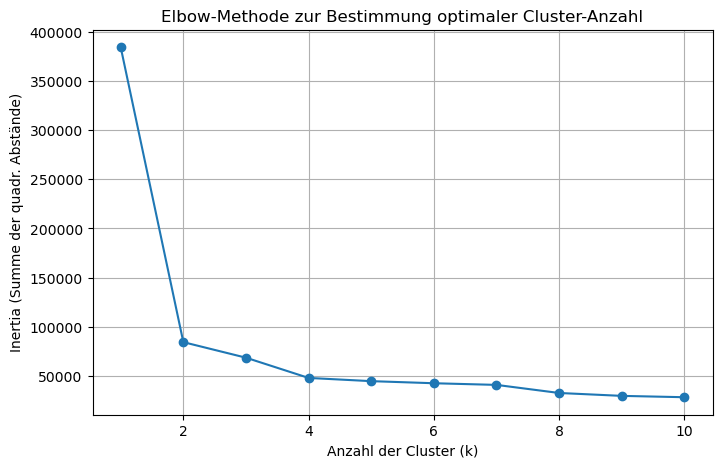

In [83]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Inertia-Werte für k = 1 bis 10 sammeln
inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Plot erstellen
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Anzahl der Cluster (k)')
plt.ylabel('Inertia (Summe der quadr. Abstände)')
plt.title('Elbow-Methode zur Bestimmung optimaler Cluster-Anzahl')
plt.grid(True)
plt.show()


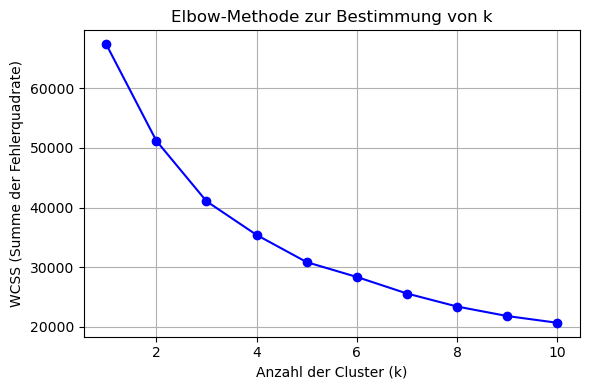

In [92]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


# Optional: nur numerische Spalten verwenden
numerische_daten = df.select_dtypes(include='number')

# Daten standardisieren
scaler = StandardScaler()
standardisierte_daten = scaler.fit_transform(numerische_daten)

# Elbow-Methode: verschiedene Cluster-Anzahlen ausprobieren
wcss = []  # WCSS = within-cluster sum of squares (Streuungsmaß)

k_bereich = range(1, 11)
for k in k_bereich:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(standardisierte_daten)
    wcss.append(kmeans.inertia_)  # inertia_ = Summe der quadrierten Abstände innerhalb der Cluster

# Plot der Elbow-Kurve
plt.figure(figsize=(6, 4))
plt.plot(k_bereich, wcss, 'bo-')
plt.xlabel('Anzahl der Cluster (k)')
plt.ylabel('WCSS (Summe der Fehlerquadrate)')
plt.title('Elbow-Methode zur Bestimmung von k')
plt.grid(True)
plt.tight_layout()
plt.show()


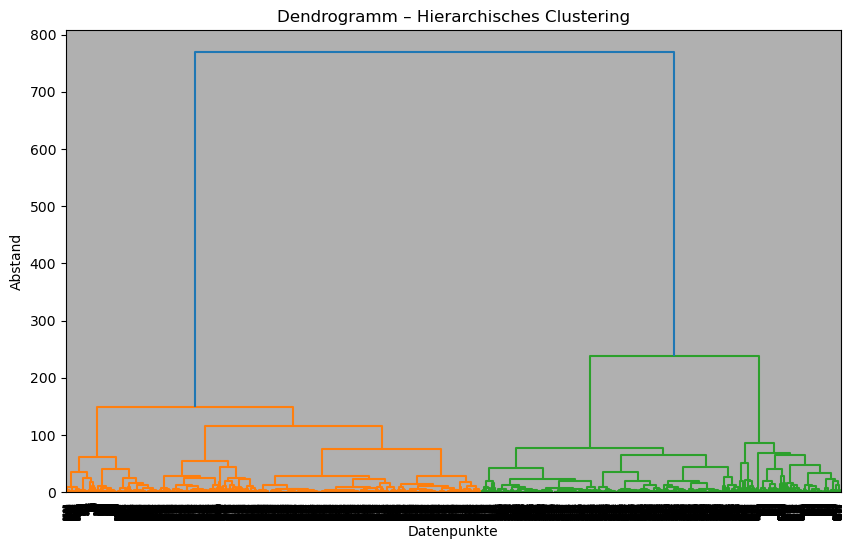

In [93]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

# Dendrogramm erzeugen
plt.figure(figsize=(10, 6))
dendrogram = sch.dendrogram(sch.linkage(df_scaled, method='ward'))

plt.title('Dendrogramm – Hierarchisches Clustering')
plt.xlabel('Datenpunkte')
plt.ylabel('Abstand')
plt.grid(True)
plt.show()

In [94]:
from sklearn.cluster import AgglomerativeClustering

# 3 Cluster zuweisen (z. B. basierend auf Dendrogramm)
model = AgglomerativeClustering(n_clusters=3, affinity='euclidean', linkage='ward')
df['Cluster'] = model.fit_predict(df_scaled)

print(df)


TypeError: AgglomerativeClustering.__init__() got an unexpected keyword argument 'affinity'

### Modell mit transformationen

In [44]:
from sklearn.cluster import KMeans

# Modell mit 2 Clustern
kmeans = KMeans(n_clusters=6, random_state=0)
df_encoded['Cluster'] = kmeans.fit_predict(df_scaled)

#df_encoded.head()
df_scaled.head()

,year,price,mileage,tax,mpg,engineSize,model_num,model_ A1,model_ A3,model_ A4,...,model_ Q3,model_ Q5,model_ RS3,model_ S3,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Petrol,Cluster
0,0.625,0.137525,0.192129,0.7,0.503922,0.266667,0.000000,True,False,False,...,False,False,False,False,False,True,False,False,True,3
3,0.625,0.245025,0.316922,0.6,0.737255,0.666667,0.157895,False,False,True,...,False,False,False,False,True,False,False,True,False,5
4,0.875,0.257525,0.024343,0.6,0.390196,0.000000,0.105263,False,True,False,...,False,False,False,False,False,True,False,False,True,3
10,0.625,0.227525,0.353601,0.6,0.572549,0.266667,0.105263,False,True,False,...,False,False,False,False,False,True,False,False,True,3
11,0.500,0.237525,0.637495,0.2,0.547059,0.666667,0.263158,False,False,False,...,False,False,False,False,True,False,False,True,False,2


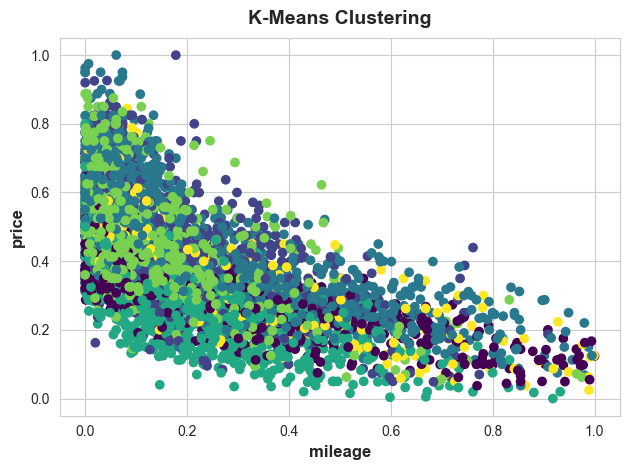

In [45]:
import matplotlib.pyplot as plt

plt.scatter(df_scaled['mileage'], df_scaled['price'], c=df_scaled['Cluster'], cmap='viridis')
plt.xlabel('mileage')
plt.ylabel('price')
plt.title('K-Means Clustering')
plt.grid(True)
plt.show()


## 5 - Evaluation (Bewertung)
- Bewertung des Modells
- Bewertung der Resultate
- Bewertung des Prozesses
- Nächste Schritte festlegen

---

### 5.1 Bewertung des Modells

### Sílhouette Score

In [95]:
from sklearn.metrics import silhouette_score

# Beispiel: X_scaled = normierte Daten, labels = Clustervorhersagen
score = silhouette_score(X, X['Cluster'])
print(f'Silhouette Score: {score:.3f}')


Silhouette Score: 0.423


### 5.2 Bewertung der Resultate

### 5.3 Bewertung des Prozesses

### 5.4 Nächste Schritte festlegen

## 6 - Deployment (Anwendung)
- Zusammenfassender Bericht und Präsentation der Ergebnisse
- Implementierungs-strategie planen
- Überwachung der Gültigkeit der Modelle planen
- ---

In [67]:
# DataFrame als CSV speichern
X.to_csv('cluster.csv', index=False)